# Extension 1 — Dynamic misspecification: VARMA(4,1) DGP (Ch. 4)

Stress-tests the Ch. 3 baseline ranking under **dynamic misspecification**. The DGP augments the baseline with a first-order moving-average term,
$$ y_t = \sum_{i=1}^4 A_i y_{t-i} + u_t + \Theta u_{t-1}, \qquad \Theta=\theta I_2,\quad u_t=B\varepsilon_t,\quad \varepsilon_t\sim\mathcal N(0,I_2), $$
with misspecification strength $\theta\in\{0.1,0.3,0.6\}$ ($\theta=0$ nests the baseline VAR(4)). The lag matrices $A_i$ and impact matrix $B$ are inherited from the baseline, so **all** variation is the MA component.

The VARMA is invertible, so it admits a VAR($\infty$) representation: a high-order VAR($q$) can approximate it, the equal-lag **VAR(4)** cannot (it carries an asymptotic bias that does not vanish with $T$), and **LP(4)** is robust by construction \[Montiel Olea et al.\]. Estimators (fixed **LP(4)** and the **VAR($q$) sweep**, $q=1\ldots p+H-1$) are applied **unchanged**; the estimand is the true VARMA structural IRF $\theta_h=(\Phi_h B)[1,1]$, computed analytically per $\theta$.

In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from mcsim.dgp import (VARSpec, VARMASpec, simulate_varma, varma_irf,
                       scale_to_persistence, spectral_radius)
from mcsim.estimators import estimate_lp_irf, estimate_var_irf, fit_var_ols
from mcsim.simulation import MCConfig, run

## 0. Set up model parameters

In [2]:
# Define the persistence scenario to run. Can be "LOW" (rho = 0.5), "MID" (rho = 0.7), "High" (rho = 0.95)
Scenario = "HIGH"

In [3]:
SEED = 42                                            # master RNG seed for all stochastic processes
P = 4
H= 20
RHO_SCENARIO = {"LOW": 0.5, "MID": 0.7, "HIGH": 0.95}
RHO = RHO_SCENARIO[Scenario]                                          # Rho in {0.5, 0.7, 0.95}

T = [100, 250, 500]
THETAS = [0.0, 0.1, 0.3, 0.6]    # MA misspecification strength (theta=0 nests baseline VAR(4))
T_SHOW = 250                     # sample size used for the per-theta diagnostic panels

M  = np.array([[0.50, 0.10], [0.10, 0.50]])      # symmetric, positive -> real, decaying
A0 = np.array([M, 0.4 * M, 0.2 * M, 0.1 * M])     # VAR(4): geometrically decaying lag matrices
B  = np.array([[1.0, 0.0], [0.5, 1.0]])           # recursive (lower-triangular) impact matrix
A_RHO = scale_to_persistence(A0, RHO)             # AR part scaled to target persistence; shared across theta

# VARMA(4,1) with Theta_1 = theta * I_2; theta=0 reproduces the baseline VAR(4) exactly.
DGPS = {th: VARMASpec(A=A_RHO, Theta=np.array([th * np.eye(2)]), B=B) for th in THETAS}
print("AR spectral radius (persistence):", round(spectral_radius(A_RHO), 3),
      "| MA(1) root modulus 1/theta > 1 for theta<1 -> invertible (VAR-infinity exists)")

N_REPS = 5000  # nr of MC reps

AR spectral radius (persistence): 0.95 | MA(1) root modulus 1/theta > 1 for theta<1 -> invertible (VAR-infinity exists)


## 1. DGP — the MA term distorts the IRF and leaves serially correlated VAR residuals

**Left:** the true structural estimand $\theta_h=(\Phi_h B)[1,1]$ for each $\theta$ — the MA term $\Theta u_{t-1}$ injects extra **short-horizon** propagation that lifts the early-horizon IRF; $\theta=0$ recovers the baseline VAR(4). **Middle:** the autocorrelation of the **squared** residuals from an equal-lag **VAR(4)** fit to the VARMA(4,1) data — it stays inside the band for every $\theta$, so the innovations are conditionally **homoskedastic** (no volatility clustering). **Right:** the same diagnostic on the **level** residuals — white at $\theta=0$ but developing **serial correlation** as $\theta$ grows, breaking the band at $\theta=0.6$ (concentrated near lag 4): the equal-lag VAR(4) cannot absorb the MA component, so it leaves autocorrelated residuals. This is a *dynamic* misspecification and the **mirror image** of the nonlinear extension (where the levels stay white and the squares cluster). *Significance band.* The shaded region is the **Bartlett white-noise band** $\pm 1.96/\sqrt{N}$ ($N$ = residual series length, $\approx 4000-P$): under the null that the residuals are white (serially uncorrelated), the sample autocorrelations are asymptotically $\hat\rho_k \sim N(0, 1/N)$, so points outside the band reject white-noise at the 5% level.

/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_19997/4048997070.py:26: RuntimeWarning: divide by zero encountered in matmul
  x = x - x.mean(); v = x @ x
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_19997/4048997070.py:26: RuntimeWarning: overflow encountered in matmul
  x = x - x.mean(); v = x @ x
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_19997/4048997070.py:26: RuntimeWarning: invalid value encountered in matmul
  x = x - x.mean(); v = x @ x
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_19997/4048997070.py:27: RuntimeWarning: divide by zero encountered in matmul
  return np.array([1.0] + [(x[l:] @ x[:-l]) / v for l in range(1, L + 1)])
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_19997/4048997070.py:27: RuntimeWarning: overflow encountered in matmul
  return np.array([1.0] + [(x[l:] @ x[:-l]) / v for l in range(1, L + 1)])
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_19997/4048997070.py:27: RuntimeWar

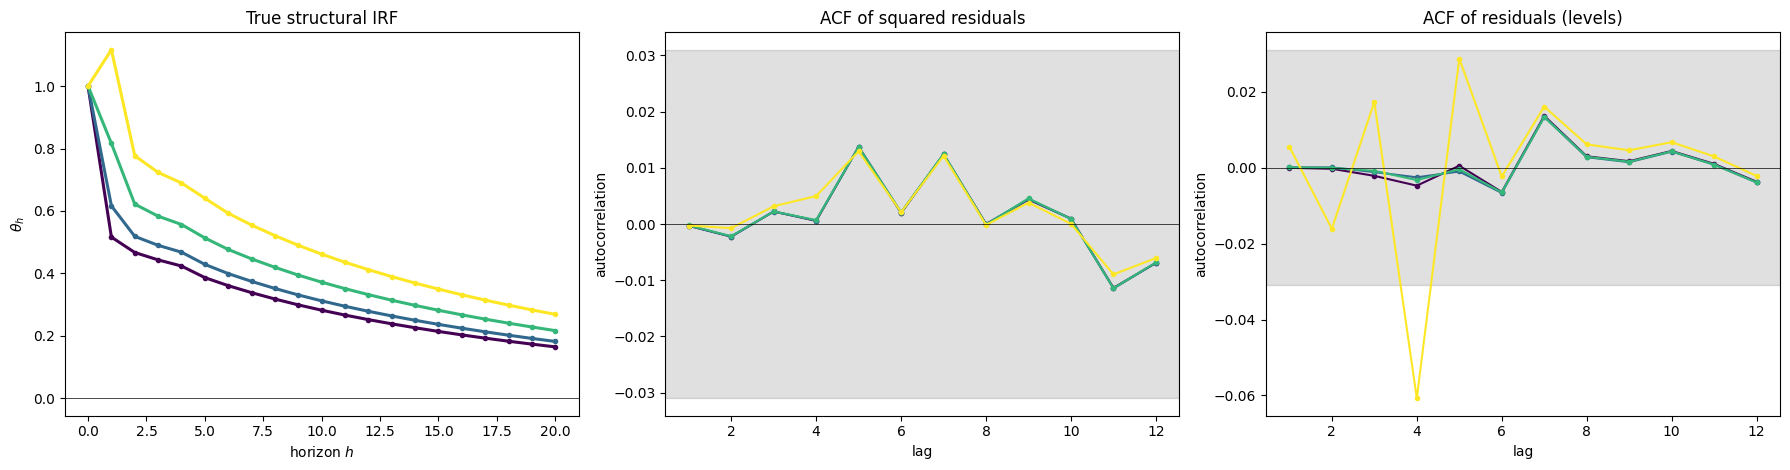

In [4]:
# True structural IRFs (no estimation) for each misspecification strength, plus the
# residual diagnostics that reveal *why* the equal-lag VAR(4) is misspecified here:
# (a) the true estimand theta_h per theta; (b) & (c) the ACF of a VAR(4) fit's residuals.
# Under VARMA(4,1) the four lags cannot absorb the MA term, so the *level* residuals retain
# serial correlation (lifts with theta), while the *squared* residuals stay white -- the
# misspecification is dynamic, not heteroskedastic (the mirror of the nonlinear extension).
hgrid = np.arange(H + 1)
truth_byTheta = {th: varma_irf(DGPS[th], H) for th in THETAS}
cth = {th: plt.cm.viridis(i / max(len(THETAS) - 1, 1)) for i, th in enumerate(THETAS)}

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# (a) true structural IRF: the MA term lifts the short-horizon estimand
ax = axes[0]
for th in THETAS:
    lab = "θ=0  (baseline VAR(4))" if th == 0 else f"θ={th}"
    ax.plot(hgrid, truth_byTheta[th], "o-", lw=2.2, ms=3, color=cth[th], label=lab)
ax.axhline(0, color="k", lw=0.5)
ax.set_title("True structural IRF")
ax.set_xlabel("horizon $h$"); ax.set_ylabel(r"$\theta_h$")

# (b) & (c) residual diagnostics on VAR(4) residuals of VARMA(4,1) paths (eq-1, the response y1):
#           levels carry the leftover MA serial correlation, squares stay white.
N_ACF, L_ACF = 4000, 12
def _acf(x, L=L_ACF):
    x = x - x.mean(); v = x @ x
    return np.array([1.0] + [(x[l:] @ x[:-l]) / v for l in range(1, L + 1)])
for th in THETAS:
    acf_sq, acf_lvl = [], []
    for s in np.random.SeedSequence(SEED).spawn(8):                # average several long paths
        y = simulate_varma(DGPS[th], N_ACF, np.random.default_rng(s))
        with np.errstate(all="ignore"):
            _, _, res = fit_var_ols(y, P)
        acf_sq.append(_acf(res[:, 0] ** 2))                        # squared eq-1 residual -> should stay white
        acf_lvl.append(_acf(res[:, 0]))                            # level  eq-1 residual -> retains MA serial corr.
    lab = "θ=0 (baseline)" if th == 0 else f"θ={th}"
    axes[1].plot(range(1, L_ACF + 1), np.nanmean(acf_sq, 0)[1:], "o-", ms=3, color=cth[th], label=lab)
    axes[2].plot(range(1, L_ACF + 1), np.nanmean(acf_lvl, 0)[1:], "o-", ms=3, color=cth[th], label=lab)

# Bartlett white-noise band. Null: the residual series is serially uncorrelated (white); under
# that null the sample ACF is asymptotically rho_hat_k ~ N(0, 1/N), so the two-sided 95% band is
# 0 +/- 1.96/sqrt(N). (b) squares stay inside -> homoskedastic; (c) levels break out as theta grows
# -> the MA serial correlation the equal-lag VAR(4) cannot absorb. N = residual series length.
band = 1.96 / np.sqrt(N_ACF - P)
for ax, ttl in ((axes[1], "ACF of squared residuals"), (axes[2], "ACF of residuals (levels)")):
    ax.axhline(0, color="k", lw=0.5)
    ax.axhspan(-band, band, color="black", alpha=0.12, label="95% white-noise band")
    ax.set_title(ttl); ax.set_xlabel("lag"); ax.set_ylabel("autocorrelation")
# fig.suptitle("VARMA(4,1): MA lifts the IRF; VAR(4) residuals stay homoskedastic but serially correlated", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_IRF_rho={RHO}.png")
plt.show()

## 2. Monte Carlo — LP(4) + VAR(q) sweep × misspecification × sample size

The three-way design of Ch. 4: for each $\theta\in\{0,0.1,0.3,0.6\}$ and $T\in\{100,250,500\}$ we run the fixed **LP(4)** and the full **VAR(q) sweep** ($q=1\ldots23$) on VARMA-generated data, **without modification**. The estimand is $T$-independent but **$\theta$-dependent** (`truth_byTheta`). Raw stacks land in `results[(θ,T)]` and horizon-wise RMSE in `rmse[(θ,T)]`.

In [5]:
VAR_ORDERS = list(range(1, P + H))                  # 1, 2, ..., 22, 23

estimators = {"LP(4)": partial(estimate_lp_irf, p=P, horizon=H)}
estimators.update({f"VAR({q})": partial(estimate_var_irf, p=q, horizon=H) for q in VAR_ORDERS})


def varma_dgp(rng, Tlen, spec):
    return simulate_varma(spec, Tlen, rng)


results, rmse = {}, {}                               # keyed by (theta, T)
for th in THETAS:
    truth = truth_byTheta[th]                        # estimand depends on theta
    for Tval in T:
        cfg = MCConfig(n_reps=N_REPS, T=Tval, horizon=H, seed=SEED, n_jobs=-1,
                       progress=True, estimators=estimators)
        res = run(partial(varma_dgp, spec=DGPS[th]), cfg)
        results[(th, Tval)] = res
        rmse[(th, Tval)] = {nm: np.sqrt(np.nanmean((st - truth) ** 2, axis=0))
                            for nm, st in res["irfs"].items()}
        fails = {k: v for k, v in res["n_failures"].items() if v}
        print(f"theta={th:<4} T={Tval:>4}: done  |  failures: {fails or 'none'}")

MC reps: 100%|██████████| 5000/5000 [00:03<00:00, 1349.15it/s]


theta=0.0  T= 100: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:05<00:00, 973.14it/s] 


theta=0.0  T= 250: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:07<00:00, 666.67it/s]


...

theta=0.6  T= 100: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:11<00:00, 420.28it/s]


theta=0.6  T= 250: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:15<00:00, 328.38it/s]


theta=0.6  T= 500: done  |  failures: none


## 3. RMSE comparison: does the ranking survive misspecification?

The **complexity frontier** (horizon-averaged RMSE vs VAR order) at $T=250$, one curve per $\theta$, with LP(4) as a same-colour dashed reference. As $\theta$ grows the equal-lag (VAR(4)) end of the frontier should lift — four lags cannot fit the MA dynamics — while higher-order VARs and LP(4) absorb it. The table reports every $(\theta,T)$ cell.

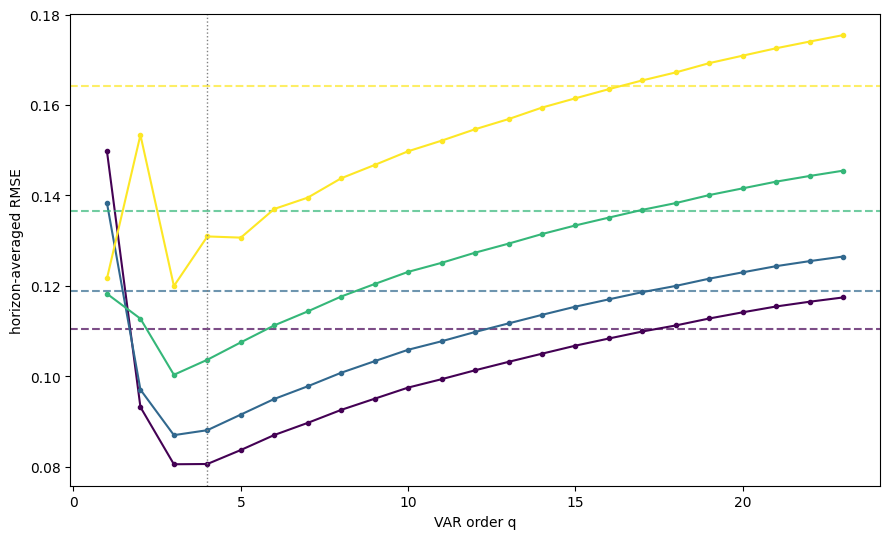

 theta     T    LP(4)   VAR(4)        bestVAR   LP-VAR4
--------------------------------------------------------
   0.0   100    0.197    0.137   VAR(3)=0.133    +0.060
   0.0   250    0.110    0.081   VAR(3)=0.081    +0.030
   0.0   500    0.074    0.054   VAR(4)=0.054    +0.020
   0.1   100    0.213    0.150   VAR(3)=0.145    +0.063
   0.1   250    0.119    0.088   VAR(3)=0.087    +0.031
   0.1   500    0.080    0.059   VAR(4)=0.059    +0.020
   0.3   100    0.246    0.177   VAR(3)=0.169    +0.068
   0.3   250    0.137    0.104   VAR(3)=0.100    +0.033
   0.3   500    0.091    0.070   VAR(3)=0.068    +0.022
   0.6   100    0.297    0.222   VAR(1)=0.195    +0.075
   0.6   250    0.164    0.131   VAR(3)=0.120    +0.033
   0.6   500    0.109    0.089   VAR(3)=0.082    +0.021
(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)


In [6]:
# (1) complexity frontier per theta, at T_SHOW
fig, ax = plt.subplots(figsize=(9, 5.5))
for th in THETAS:
    rm = rmse[(th, T_SHOW)]
    avg_var = [np.mean(rm[f"VAR({q})"]) for q in VAR_ORDERS]
    lab = "θ=0 (baseline)" if th == 0 else f"θ={th}"
    ax.plot(VAR_ORDERS, avg_var, "o-", ms=3, color=cth[th], label=lab)
    ax.axhline(np.mean(rm["LP(4)"]), ls="--", color=cth[th], alpha=0.7)
ax.axvline(4, color="gray", ls=":", lw=1)
# ax.set_title(f"Complexity frontier across θ  (T={T_SHOW};  solid = VAR(q), dashed = LP(4), same color), ρ={RHO} ({Scenario})")
ax.set_xlabel("VAR order q"); ax.set_ylabel("horizon-averaged RMSE")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_COMPLEXITY_FRONTIER_rho={RHO}_T={T_SHOW}.png")
plt.show()

# (2) full (theta, T) summary table
print(f"{'theta':>6} {'T':>5} {'LP(4)':>8} {'VAR(4)':>8} {'bestVAR':>14} {'LP-VAR4':>9}")
print("-" * 56)
for th in THETAS:
    for Tval in T:
        rm = rmse[(th, Tval)]
        lp = float(np.mean(rm["LP(4)"])); v4 = float(np.mean(rm["VAR(4)"]))
        avgs = {q: float(np.mean(rm[f"VAR({q})"])) for q in VAR_ORDERS}
        bq = min(avgs, key=avgs.get)
        print(f"{th:>6} {Tval:>5} {lp:8.3f} {v4:8.3f} {f'VAR({bq})={avgs[bq]:.3f}':>14} {lp - v4:+9.3f}")
print("(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)")

## 5. Point-estimation metrics under misspecification (Ch. 3 metrics)

Same per-horizon **bias / variance / MSE / RMSE** decomposition as the baseline, now at the strongest misspecification $\theta=0.6$, $T=250$. Unlike the correctly-specified baseline (VAR bias ≈ 0), here low-order VARs carry genuine bias, so $\mathrm{MSE}_h=\mathrm{Bias}_h^2+\mathrm{Var}_h$ has a non-negligible squared-bias component at short horizons. $\mathrm{MCSE}(\widehat{\mathrm{Bias}}_h)=\sqrt{\widehat{\mathrm{Var}}_h/B}$ bounds simulation noise.

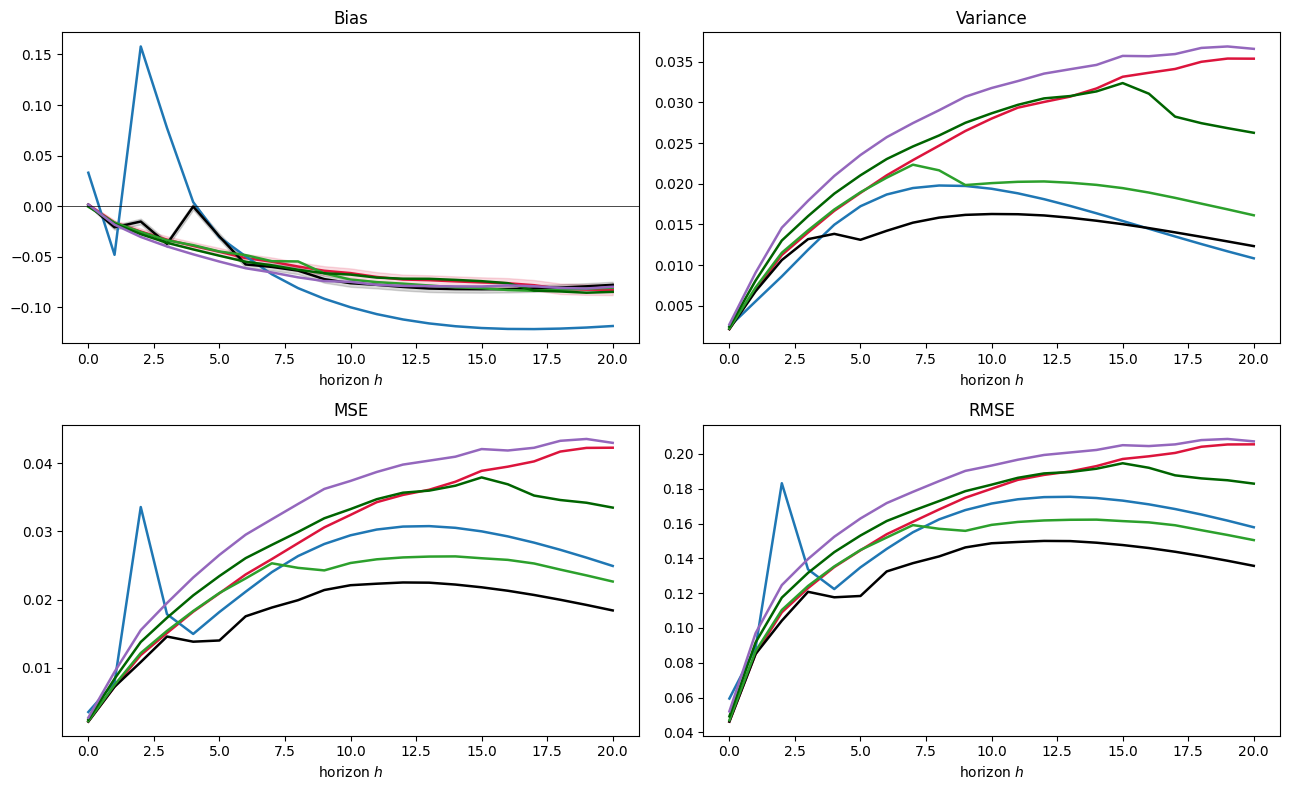

θ=0.6, T=250, B=5000   |   typical MCSE(bias) ~ 0.0015


h=1             h=8            h=20        
           bias    RMSE    bias    RMSE    bias    RMSE
LP(4)   -0.0164  0.0851 -0.0598  0.1681 -0.0829  0.2055
VAR(2)  -0.0483  0.0887 -0.0812  0.1624 -0.1187  0.1579
VAR(4)  -0.0211  0.0850 -0.0639  0.1411 -0.0780  0.1357
VAR(8)  -0.0164  0.0866 -0.0548  0.1570 -0.0808  0.1505
VAR(16) -0.0175  0.0917 -0.0631  0.1729 -0.0849  0.1829
VAR(23) -0.0184  0.0970 -0.0706  0.1844 -0.0799  0.2072

In [7]:
import pandas as pd
from IPython.display import display


def metrics(stack, truth):
    """Per-horizon Ch. 3 point metrics for a (B, H+1) stack of IRF estimates."""
    B = int(np.sum(~np.isnan(stack[:, 0])))
    mean = np.nanmean(stack, axis=0)
    bias = mean - truth
    var = np.nanvar(stack, axis=0, ddof=1)
    mse = np.nanmean((stack - truth) ** 2, axis=0)
    return dict(bias=bias, var=var, mse=mse, rmse=np.sqrt(mse),
                mcse_bias=np.sqrt(var / B), B=B)


TH_SHOW, Tval = 0.6, T_SHOW                          # strongest misspecification cell
truth = truth_byTheta[TH_SHOW]
sel = ["LP(4)", "VAR(2)", "VAR(4)", "VAR(8)", "VAR(16)", "VAR(23)"]
colm = {"LP(4)": "crimson", "VAR(2)": "tab:blue", "VAR(4)": "black",
        "VAR(8)": "tab:green", "VAR(16)": "darkgreen", "VAR(23)": "tab:purple"}
m = {nm: metrics(results[(TH_SHOW, Tval)]["irfs"][nm], truth) for nm in sel}

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for nm in sel:
    ax[0, 0].plot(hgrid, m[nm]["bias"], color=colm[nm], lw=1.8, label=nm)
    ax[0, 1].plot(hgrid, m[nm]["var"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 0].plot(hgrid, m[nm]["mse"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 1].plot(hgrid, m[nm]["rmse"], color=colm[nm], lw=1.8, label=nm)
for nm in ("LP(4)", "VAR(4)"):                       # MCSE band on bias (sim. uncertainty)
    lo, hi = m[nm]["bias"] - 1.96 * m[nm]["mcse_bias"], m[nm]["bias"] + 1.96 * m[nm]["mcse_bias"]
    ax[0, 0].fill_between(hgrid, lo, hi, color=colm[nm], alpha=0.15)
ax[0, 0].axhline(0, color="k", lw=0.5)
ax[0, 0].set_title("Bias")
ax[0, 1].set_title("Variance"); ax[1, 0].set_title("MSE"); ax[1, 1].set_title("RMSE")
for a in ax.ravel():
    a.set_xlabel("horizon $h$")
# fig.suptitle(f"Point metrics under misspecification, θ={TH_SHOW}, T={Tval}, B={N_REPS}, ρ={RHO} ({Scenario})",
#             fontweight="bold")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_POINT_ESTIMATION_rho={RHO}_T={T_SHOW}_B=5000_theta={TH_SHOW}.png")
plt.show()

# compact table: bias and RMSE at selected horizons
report = [1, 8, 20]
rows = {nm: {(f"h={h}", k): m[nm][{"bias": "bias", "RMSE": "rmse"}[k]][h]
             for h in report for k in ("bias", "RMSE")} for nm in sel}
tab = pd.DataFrame(rows).T
tab.columns = pd.MultiIndex.from_tuples(tab.columns)
print(f"θ={TH_SHOW}, T={Tval}, B={N_REPS}   |   typical MCSE(bias) ~ "
      f"{np.mean([m['VAR(4)']['mcse_bias'][h] for h in report]):.4f}")
display(tab.round(4))

## 6. Inference — coverage under misspecification (Ch. 3)

Coverage of nominal 95% CIs for the **true** VARMA $\theta_h$. The CI machinery is unchanged from the baseline:

* **VAR(q): delta method** — propagates reduced-form coefficient uncertainty through $\theta_h=\hat\Psi_h\hat B e_1$ (variance only; $B$ held fixed).
* **LP(4): HC1-robust SE** of the shock coefficient.

A variance-only CI ignores bias, so under misspecification it can only *miss* the truth more often as bias grows. At the empirically relevant $T=250$ both estimators **mildly under-cover**, worst at the short horizons where the MA term bites, and by similar amounts — consistent with §4 (comparable finite-sample bias; LP's shock is itself identified from a misspecified VAR(4)). The validation panel (delta SE vs empirical SD at $\theta=0.6$) confirms the SE still tracks the sampling dispersion, so the under-coverage is a *bias* effect, not a broken SE.

coverage MC θ=0.6: 100%|██████████| 5000/5000 [00:09<00:00, 542.36it/s]


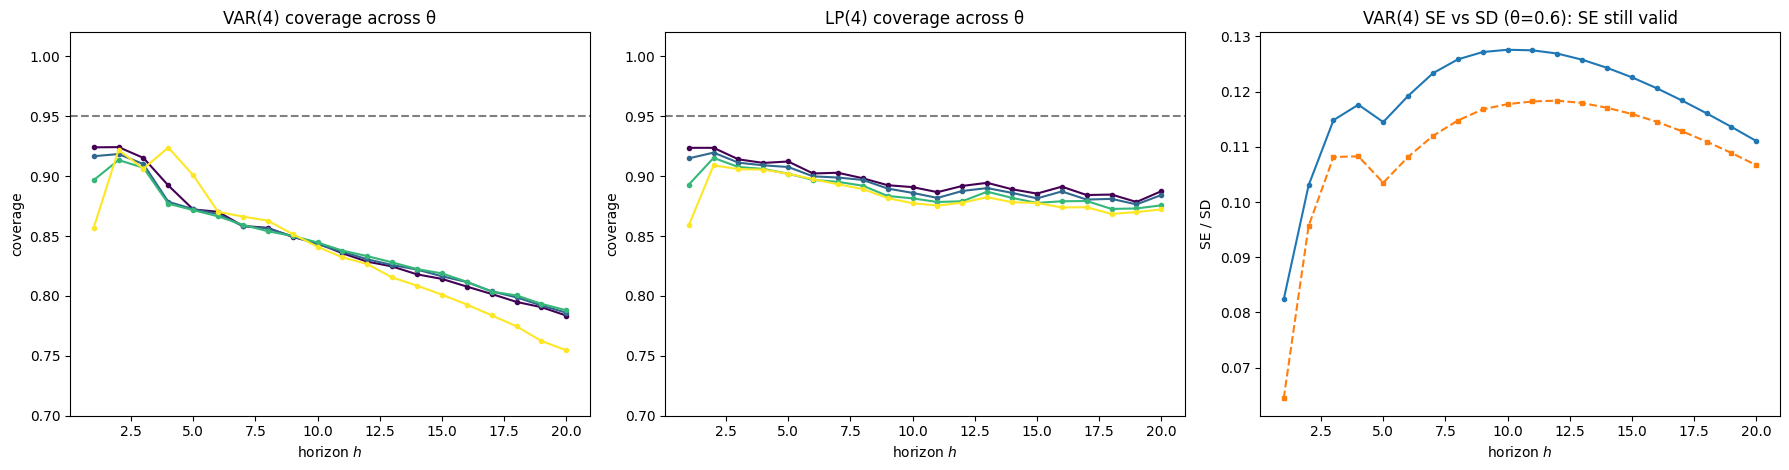

horizon-averaged coverage (h=1..20):
   VAR(4): θ=0.0:0.845   θ=0.1:0.845   θ=0.3:0.844   θ=0.6:0.838
    LP(4): θ=0.0:0.897   θ=0.1:0.893   θ=0.3:0.888   θ=0.6:0.883


In [8]:
from joblib import Parallel, delayed
from tqdm import tqdm
from mcsim.dgp import var_ma_matrices
from mcsim.estimators import fit_var_ols
from mcsim.coverage import var_theta_se, lp_theta_se

T_COV = T_SHOW         # one sample-size cell (Ch. 3 would sweep T as in section 2)
N_COV = 5000           # replications for the coverage MC
Z = 1.96               # normal critical value for a nominal 95% two-sided CI
EST_COV = ["VAR(4)", "LP(4)"]   # headline pair: misspecified equal-lag VAR vs robust LP

def _coverage_rep(seed, spec):
    """One replication: simulate from the VARMA spec, return {estimator: (theta_hat, se)}."""
    rng = np.random.default_rng(seed)
    y = simulate_varma(spec, T_COV, rng)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return {"VAR(4)": var_theta_se(y, 4, H),
                "LP(4)":  lp_theta_se(y, 4, H)}


coverage = {}          # theta -> {estimator: coverage_h}
val = {}               # SE-vs-SD validation at the strongest theta
for th in THETAS:
    tr = truth_byTheta[th]
    # Independent, reproducible RNG stream per replication (parallel-safe), as in mcsim.run.
    seeds = np.random.SeedSequence(SEED).spawn(N_COV)
    reps = Parallel(n_jobs=-1)(delayed(_coverage_rep)(s, DGPS[th])
                               for s in tqdm(seeds, desc=f"coverage MC θ={th}"))
    theta_s = {nm: np.array([r[nm][0] for r in reps]) for nm in EST_COV}
    se_s = {nm: np.array([r[nm][1] for r in reps]) for nm in EST_COV}
    # Coverage_h = fraction of CIs [theta_hat +/- Z*se] that contain the TRUE theta_h.
    coverage[th] = {nm: np.nanmean((theta_s[nm] - Z * se_s[nm] <= tr) &
                                   (tr <= theta_s[nm] + Z * se_s[nm]), axis=0) for nm in EST_COV}
    if th == 0.6:      # validation: delta-method SE should still match the empirical SD
        val = dict(emp=np.nanstd(theta_s["VAR(4)"], axis=0, ddof=1),
                   se=np.nanmean(se_s["VAR(4)"], axis=0))
        val_lp = dict(emp=np.nanstd(theta_s["LP(4)"], axis=0, ddof=1),
                      se=np.nanmean(se_s["LP(4)"], axis=0))

# --- coverage per estimator (one curve per theta) + SE validation ----------------
_ylo = float(max(0.0, np.floor((min(np.nanmin(coverage[th][nm][1:]) for th in THETAS for nm in EST_COV) - 0.02) * 20) / 20))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, nm in zip(axes[:2], EST_COV):
    for th in THETAS:
        lab = "θ=0" if th == 0 else f"θ={th}"
        ax.plot(hgrid[1:], coverage[th][nm][1:], "o-", ms=3, color=cth[th], label=lab)
    ax.axhline(0.95, color="gray", ls="--", label="nominal 0.95")
    ax.set_ylim(_ylo, 1.02); ax.set_xlabel("horizon $h$"); ax.set_ylabel("coverage")
    ax.set_title(f"{nm} coverage across θ")

axv = axes[2]
axv.plot(hgrid[1:], val["emp"][1:], "o-", ms=3, label="empirical SD of $\\hat\\theta_h$")
axv.plot(hgrid[1:], val["se"][1:], "s--", ms=3, label="mean delta-method SE")
axv.set_xlabel("horizon $h$"); axv.set_ylabel("SE / SD")
axv.set_title("VAR(4) SE vs SD (θ=0.6): SE still valid")
# fig.suptitle(f"Coverage of 95% CIs under misspecification, T={T_COV}, B={N_COV}, ρ={RHO} ({Scenario})", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_COVERAGE_rho={RHO}_T{T_SHOW}_B=5000.png")
plt.show()

print(f"horizon-averaged coverage (h=1..{H}):")
for nm in EST_COV:
    print(f"  {nm:>7}: " + "   ".join(f"θ={th}:{np.nanmean(coverage[th][nm][1:]):.3f}" for th in THETAS))